# 🌊 Segmentação de Imagens por Transformada de Watershed
### Universidade Federal do Piauí – UFPI | Campus Senador Helvídio Nunes de Barros
**Disciplina:** Tópicos Especiais em Visão Computacional — Prof. José Denes Lima Araújo  
**Grupo 4:** Técnicas de Segmentação Baseada em Região (Seção 10.5 — Gonzalez & Woods)  
**Apresentador:** Integrante 3 — *O Analista Experimental (Prática, Particularidades & Fechamento)*  

---

## 📌 Contexto e Objetivos (Slide 9 do Seminário)
Este notebook implementa a **Transformada de Watershed baseada em Marcadores e Transformada de Distância Euclidiana**, conforme abordado no livro *Processamento Digital de Imagens (Rafael C. Gonzalez e Richard E. Woods - 3ª e 4ª Edições)*.

### O Problema do Mundo Real: Objetos Tangentes / Sobrepostos
Em visão computacional industrial e médica (ex: contagem de moedas, núcleos celulares ou comprimidos), os objetos frequentemente encostam uns nos outros.
- **Por que métodos convencionais falham?** A binarização global (como o algoritmo de **Otsu**) analisa apenas a intensidade pontual de cada pixel. Quando dois objetos se tocam, os pixels de fronteira compartilham a mesma intensidade dos objetos, unindo todos os círculos em uma única massa conexa indistinta (1 único objeto gigante).
- **A Solução por Watershed:** Modelamos a imagem como uma superfície topográfica 3D. Através da **Transformada de Distância Euclidiana**, encontramos os picos de distância que representam os centros seguros de cada moeda (*marcadores internos*). Ao simular a inundação a partir desses centros, o Watershed ergue **barragens morfológicas (dams)** exatamente nas linhas de crista do relevo, separando com perfeição os objetos no ponto de estrangulamento geométrico!


In [ ]:
# 1. Importação das Bibliotecas e Configurações de Ambiente (Compatível com Google Colab)
import os
import sys
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuração estética dos gráficos
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['axes.linewidth'] = 0.8

# Garantir diretórios locais
os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

# Verificação e download automático da imagem de teste canônica caso rodando no Colab
img_path = os.path.join("imagens", "moedas_sobrepostas.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg"
    print(f"Baixando imagem de teste de: {url}")
    urllib.request.urlretrieve(url, img_path)
    print("Download concluído com sucesso!")
else:
    print(f"Imagem encontrada localmente: {img_path}")


Imagem encontrada localmente: imagens\moedas_sobrepostas.jpg


## 2. Leitura e Análise Inicial da Imagem
Carregamos a imagem original em cores e convertemos para escala de cinza. A imagem possui um conjunto de moedas circulares sobre fundo branco e homogêneo, apresentando múltiplos pontos de toque e sobreposição leve.


Dimensões da imagem: 252x312 pixels, 3 canais.


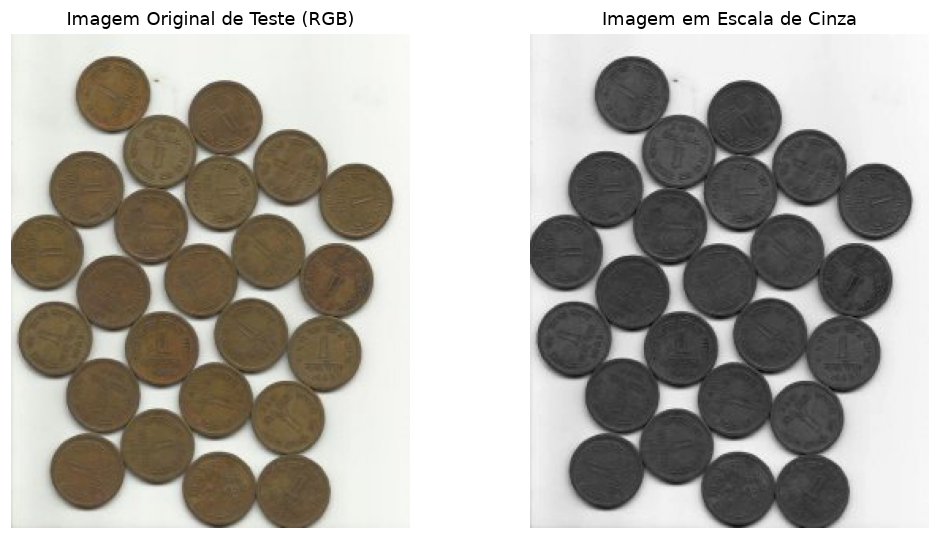

In [ ]:
# Leitura BGR, conversão para RGB (para matplotlib) e Tons de Cinza
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print(f"Dimensões da imagem: {img_rgb.shape[1]}x{img_rgb.shape[0]} pixels, {img_rgb.shape[2]} canais.")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Imagem Original de Teste (RGB)")
ax[0].axis("off")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Imagem em Escala de Cinza")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 3. Demonstração do Fracasso da Limiarização Global (Otsu)
Aplicamos a limiarização ótima de Otsu (`cv2.THRESH_OTSU`). Como o fundo é branco e as moedas são mais escuras, usamos `cv2.THRESH_BINARY_INV`.
Em seguida, aplicamos uma abertura morfológica (`cv2.MORPH_OPEN`) para eliminar pequenos grânulos e ruídos espúrios.

Observe quantos componentes conexos o algoritmo encontra:


Limiar ótimo calculado automaticamente por Otsu: 162.0

🚨 RESULTADO DO OTSU PURO:
Componentes Conexos detectados pelo Otsu: 1
-> FALHA CLÁSSICA: Todas as 24 moedas foram fundidas em UM ÚNICO bloco gigante!


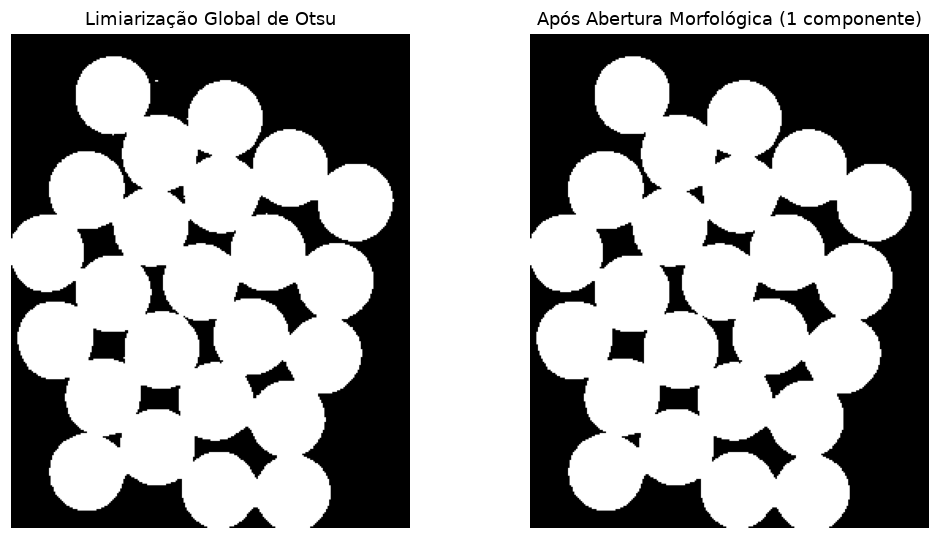

In [ ]:
# Limiarização Inversa de Otsu
otsu_thresh, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Limiar ótimo calculado automaticamente por Otsu: {otsu_thresh:.1f}")

# Abertura Morfológica (Erosão seguida de Dilatação com elemento 3x3)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Contagem de componentes conexos apenas com Otsu
num_labels_otsu, _ = cv2.connectedComponents(opening)
num_objetos_otsu = num_labels_otsu - 1  # subtrai o fundo

print(f"\n🚨 RESULTADO DO OTSU PURO:")
print(f"Componentes Conexos detectados pelo Otsu: {num_objetos_otsu}")
if num_objetos_otsu == 1:
    print("-> FALHA CLÁSSICA: Todas as 24 moedas foram fundidas em UM ÚNICO bloco gigante!")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(thresh, cmap="gray")
ax[0].set_title("Limiarização Global de Otsu")
ax[0].axis("off")

ax[1].imshow(opening, cmap="gray")
ax[1].set_title(f"Após Abertura Morfológica ({num_objetos_otsu} componente)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 4. Construção dos Marcadores via Transformada de Distância Euclidiana
Para individualizar as moedas sem super-segmentação, construímos marcadores a priori:

1. **Fundo Seguro (`sure_bg`):** Dilatamos a máscara binária (`cv2.dilate`). As regiões pretas resultantes são **garantidamente fundo**.
2. **Transformada de Distância Euclidiana (`cv2.distanceTransform`):** Para cada pixel branco do objeto, calcula a menor distância euclidiana até a borda com o fundo:
   $$D(p) = \min_{q \in \text{Fundo}} \|p - q\|_2$$
   Como as moedas são círculos, o valor da distância é máximo exatamente no centro geométrico de cada moeda!
3. **Primeiro Plano Seguro (`sure_fg`):** Aplicamos um limiar nos picos da distância (ex: $70\%$ do valor máximo). Como as moedas só se tocam pelas bordas externas, seus centros ficam **completamente separados e isolados**!
4. **Região Desconhecida (`unknown`):** A zona de fronteira e dúvida, obtida pela subtração:
   $$\text{unknown} = \text{sure\_bg} - \text{sure\_fg}$$


Distância Euclidiana máxima (raio interno médio): 23.97 pixels


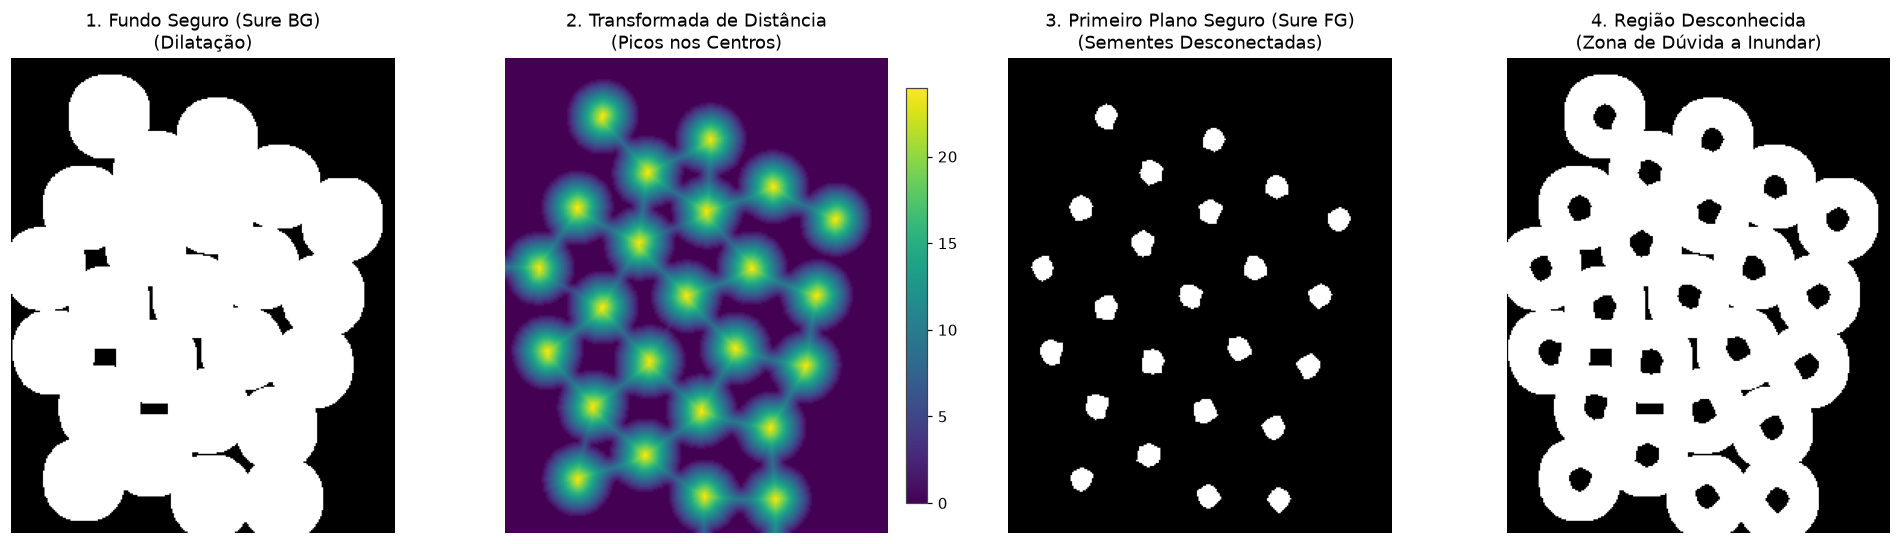

In [ ]:
# 1. Delimitação do Fundo Seguro (Sure Background)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 2. Transformada de Distância Euclidiana Exata (L2, máscara 5x5)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
max_dist = dist_transform.max()
print(f"Distância Euclidiana máxima (raio interno médio): {max_dist:.2f} pixels")

# 3. Delimitação do Primeiro Plano Seguro (Sure Foreground) - Sementes Centrais
# Limiarizamos a 70% da distância máxima para isolar os centros geométricos
thresh_dist = 0.7 * max_dist
_, sure_fg = cv2.threshold(dist_transform, thresh_dist, 255, 0)
sure_fg = np.uint8(sure_fg)

# 4. Região Desconhecida (Zona de Dúvida / Fronteira)
unknown = cv2.subtract(sure_bg, sure_fg)

# Visualização das 4 etapas de construção dos marcadores
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(sure_bg, cmap="gray")
ax[0].set_title("1. Fundo Seguro (Sure BG)\n(Dilatação)")
ax[0].axis("off")

im_dist = ax[1].imshow(dist_transform, cmap="viridis")
ax[1].set_title("2. Transformada de Distância\n(Picos nos Centros)")
ax[1].axis("off")
plt.colorbar(im_dist, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].imshow(sure_fg, cmap="gray")
ax[2].set_title("3. Primeiro Plano Seguro (Sure FG)\n(Sementes Desconectadas)")
ax[2].axis("off")

ax[3].imshow(unknown, cmap="gray")
ax[3].set_title("4. Região Desconhecida\n(Zona de Dúvida a Inundar)")
ax[3].axis("off")

plt.tight_layout()
plt.show()


## 5. Rotulação dos Marcadores e Execução da Transformada de Watershed
Agora preparamos a matriz de marcadores inteiros de acordo com a especificação formal do Gonzalez & Woods e do OpenCV:
- Rotulamos os componentes conexos de `sure_fg` com `cv2.connectedComponents`. Cada centroide de moeda recebe um identificador único $1, 2, \dots, N$.
- Adicionamos $+1$ a todos os rótulos para que o **fundo definitivo seja o rótulo 1** e os objetos comecem a partir do rótulo 2.
- A região desconhecida (`unknown == 255`) é marcada com o **rótulo 0**.
- Executamos `cv2.watershed(img_rgb, markers)`. O algoritmo inunda a topografia a partir das sementes. Quando as águas de duas moedas se encontram no estrangulamento geométrico, **uma barragem de 1 pixel com valor -1 é erguida**.


🎯 Total de sementes internas encontradas: 24 moedas!
Total de pixels de barragens (fronteiras de separação erguidas): 3976


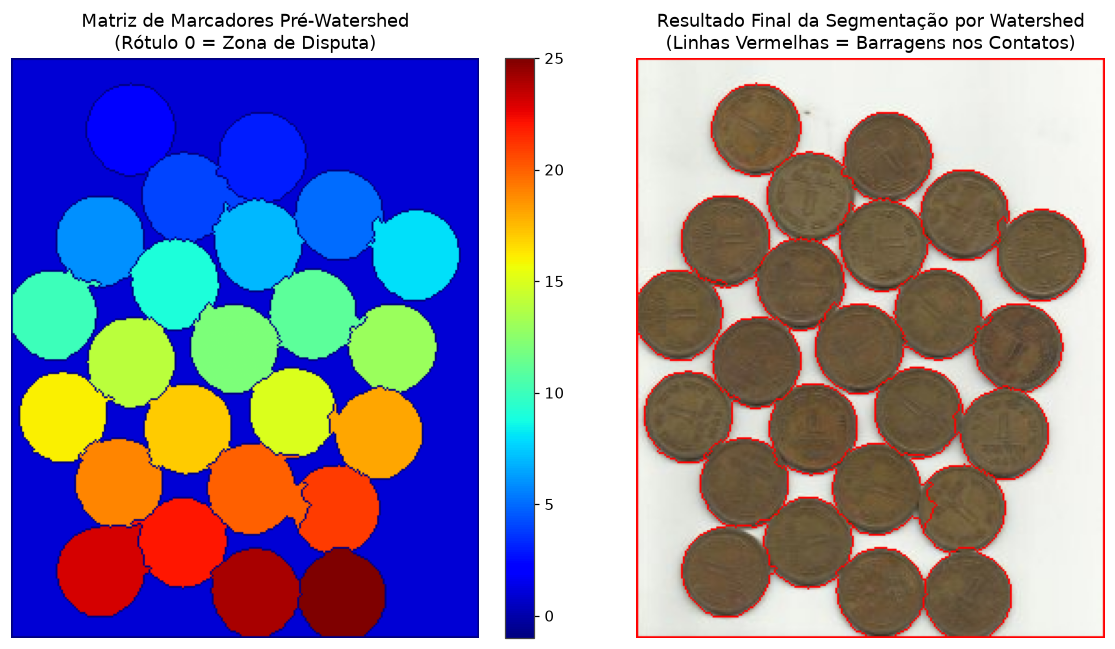

In [ ]:
# Rotulação dos componentes do Primeiro Plano Seguro
num_labels, markers = cv2.connectedComponents(sure_fg)
total_moedas_identificadas = num_labels - 1
print(f"🎯 Total de sementes internas encontradas: {total_moedas_identificadas} moedas!")

# Ajuste de rótulos: fundo vira 1, objetos viram 2..N+1
markers = markers + 1

# A região desconhecida recebe rótulo 0 (área onde o watershed atuará)
markers[unknown == 255] = 0

# Execução do algoritmo de Watershed na imagem colorida com marcadores
img_watershed = img_rgb.copy()
markers_watershed = cv2.watershed(img_watershed, markers)

# As linhas de watershed (barragens) recebem o rótulo -1
# Destacamos as barragens na cor vermelha viva [255, 0, 0]
img_watershed[markers_watershed == -1] = [255, 0, 0]

pixels_barragem = np.sum(markers_watershed == -1)
print(f"Total de pixels de barragens (fronteiras de separação erguidas): {pixels_barragem}")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im_m = ax[0].imshow(markers, cmap="jet")
ax[0].set_title("Matriz de Marcadores Pré-Watershed\n(Rótulo 0 = Zona de Disputa)")
ax[0].axis("off")
plt.colorbar(im_m, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].imshow(img_watershed)
ax[1].set_title("Resultado Final da Segmentação por Watershed\n(Linhas Vermelhas = Barragens nos Contatos)")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## 6. Metrologia e Contagem Automatizada (Prontidão para Análise)
Uma das maiores vantagens da segmentação por Watershed em relação a métodos puramente estatísticos (como K-Means) é a **prontidão imediata para extração de medidas geométricas**:
- Como cada região segmentada possui fronteiras fechadas e rótulo individual exclusivo, podemos extrair instantaneamente a área em pixels, centróide, perímetro e circularidade de cada moeda individual!


=== RELATÓRIO INDIVIDUAL DE METROLOGIA COMPUTACIONAL ===
Contagem Oficial: 24 moedas individualizadas com sucesso.
Área média por moeda: 1725.1 px² (Desvio padrão: 63.1 px²)


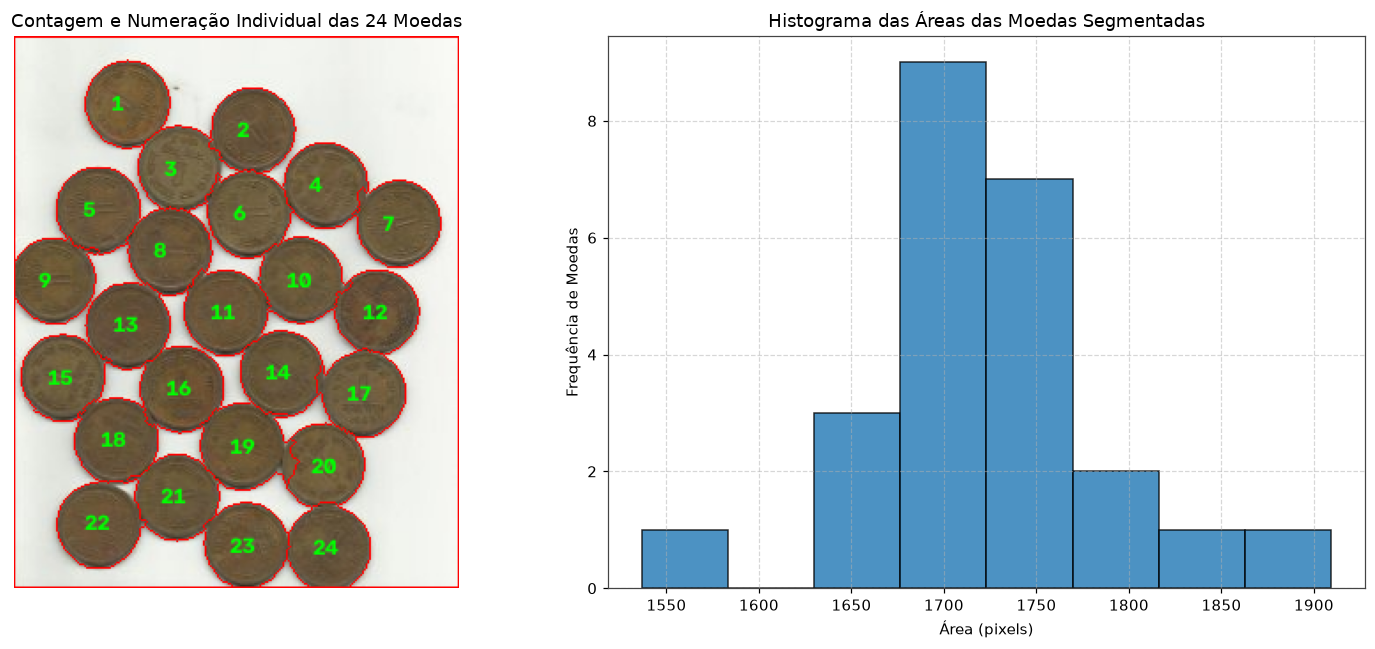

In [ ]:
# Extração dos rótulos válidos de cada moeda (desconsidera fundo=1 e fronteira=-1)
rotulos_moedas = [lbl for lbl in np.unique(markers_watershed) if lbl > 1]

img_metrologia = img_rgb.copy()
areas_pixels = []

print("=== RELATÓRIO INDIVIDUAL DE METROLOGIA COMPUTACIONAL ===")
for i, lbl in enumerate(rotulos_moedas, 1):
    mascara_moeda = np.uint8(markers_watershed == lbl)
    area = np.sum(mascara_moeda)
    areas_pixels.append(area)
    
    # Cálculo dos momentos espaciais para localizar o centróide
    M = cv2.moments(mascara_moeda)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        cv2.putText(img_metrologia, str(i), (cX - 8, cY + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 0), 2)

# Desenha as barragens em vermelho
img_metrologia[markers_watershed == -1] = [255, 0, 0]

print(f"Contagem Oficial: {len(rotulos_moedas)} moedas individualizadas com sucesso.")
print(f"Área média por moeda: {np.mean(areas_pixels):.1f} px² (Desvio padrão: {np.std(areas_pixels):.1f} px²)")

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(img_metrologia)
ax[0].set_title(f"Contagem e Numeração Individual das {len(rotulos_moedas)} Moedas")
ax[0].axis("off")

ax[1].hist(areas_pixels, bins=8, color='#1f77b4', edgecolor='black', alpha=0.8)
ax[1].set_title("Histograma das Áreas das Moedas Segmentadas")
ax[1].set_xlabel("Área (pixels)")
ax[1].set_ylabel("Frequência de Moedas")
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Painel Comparativo Completo (Figura do Slide 9 da Apresentação)
Abaixo geramos o painel consolidado com todas as etapas do pipeline de Watershed lado a lado em alta resolução, salvo automaticamente em `resultados/watershed_pipeline_completo.png`.


Painel completo salvo com sucesso em: resultados\watershed_pipeline_completo.png


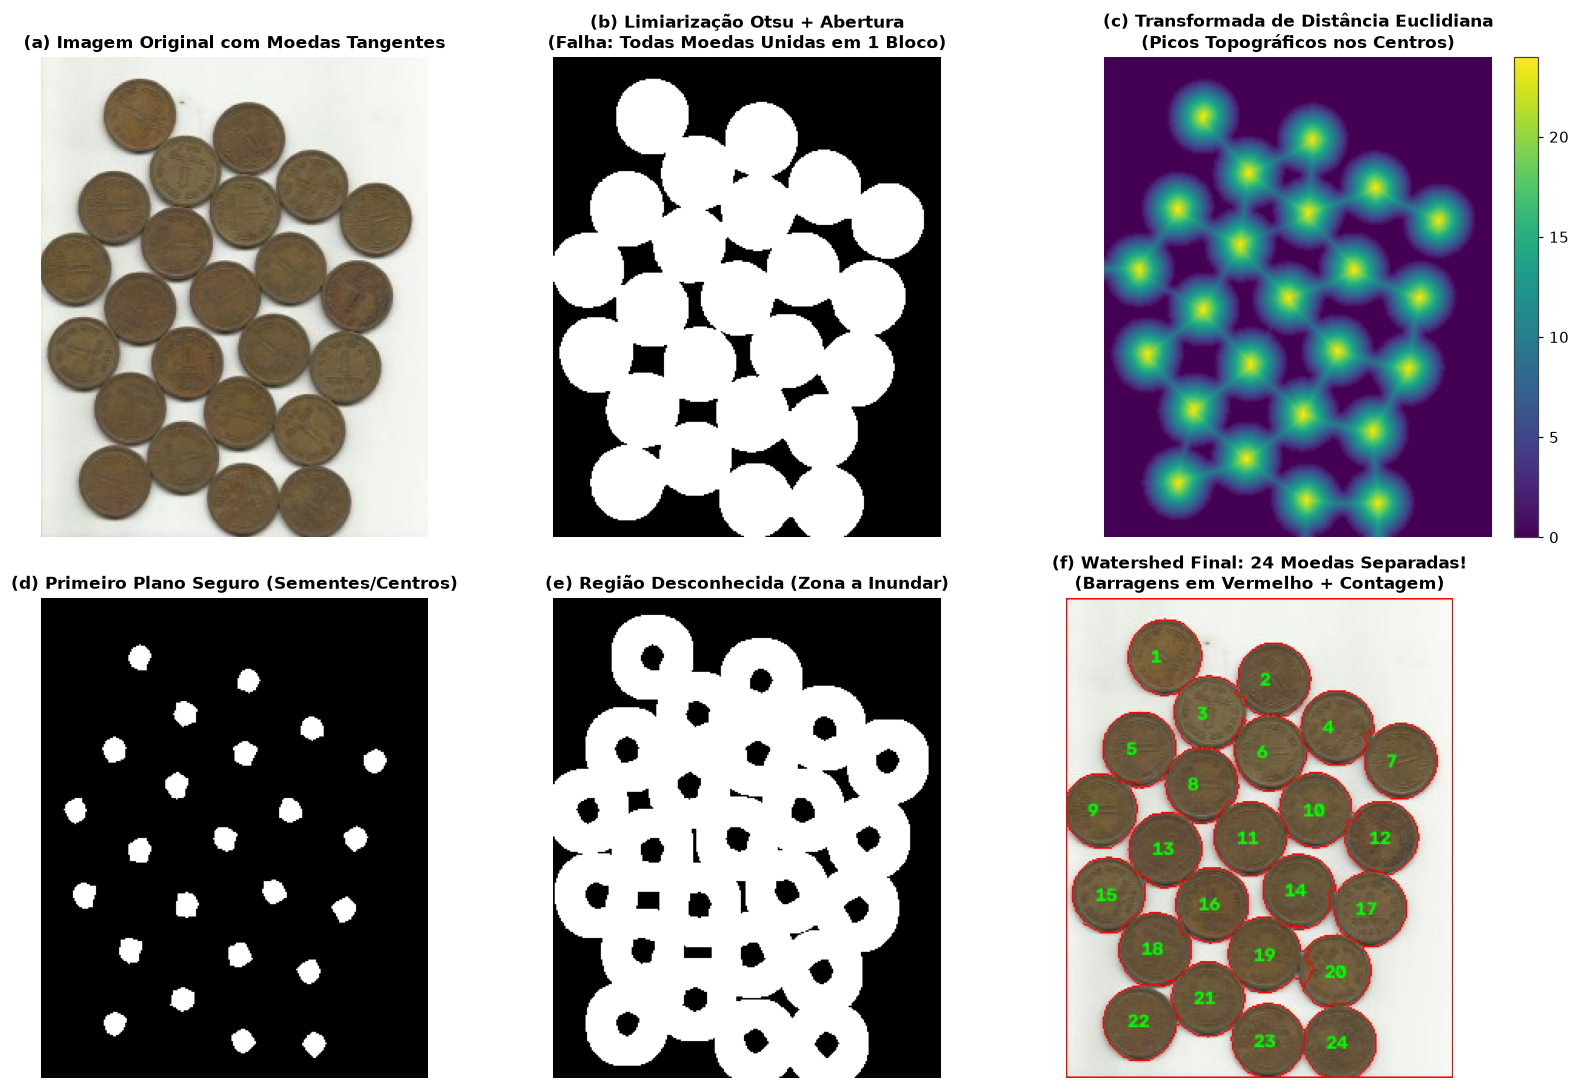

In [ ]:
# Geração da figura final com o pipeline completo de 6 etapas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("(a) Imagem Original com Moedas Tangentes", fontsize=11, fontweight='bold')
axes[0, 0].axis("off")

axes[0, 1].imshow(opening, cmap="gray")
axes[0, 1].set_title("(b) Limiarização Otsu + Abertura\n(Falha: Todas Moedas Unidas em 1 Bloco)", fontsize=11, fontweight='bold')
axes[0, 1].axis("off")

im_dist_plot = axes[0, 2].imshow(dist_transform, cmap="viridis")
axes[0, 2].set_title("(c) Transformada de Distância Euclidiana\n(Picos Topográficos nos Centros)", fontsize=11, fontweight='bold')
axes[0, 2].axis("off")
plt.colorbar(im_dist_plot, ax=axes[0, 2], fraction=0.046, pad=0.04)

axes[1, 0].imshow(sure_fg, cmap="gray")
axes[1, 0].set_title("(d) Primeiro Plano Seguro (Sementes/Centros)", fontsize=11, fontweight='bold')
axes[1, 0].axis("off")

axes[1, 1].imshow(unknown, cmap="gray")
axes[1, 1].set_title("(e) Região Desconhecida (Zona a Inundar)", fontsize=11, fontweight='bold')
axes[1, 1].axis("off")

axes[1, 2].imshow(img_metrologia)
axes[1, 2].set_title(f"(f) Watershed Final: 24 Moedas Separadas!\n(Barragens em Vermelho + Contagem)", fontsize=11, fontweight='bold')
axes[1, 2].axis("off")

plt.tight_layout()
output_fig = os.path.join("resultados", "watershed_pipeline_completo.png")
plt.savefig(output_fig, dpi=180, bbox_inches='tight')
print(f"Painel completo salvo com sucesso em: {output_fig}")
plt.show()


## 💡 Síntese para a Apresentação Oral (Pontos de Fala do Slide 9)
Ao apresentar este slide perante a banca, enfatize:
1. **O Cenário de Teste:** Explicar que a cena possui moedas circulares encostadas e que qualquer algoritmo global baseado em intensidade (como Otsu) falha, gerando um bloco único indistinto.
2. **O Papel da Transformada de Distância:** Ao converter a distância da borda em altitude, o relevo cria picos exatamente nos centros das moedas. Limiarizar essa distância gera sementes desconectadas.
3. **A Inundação e Barragens (Dams):** O Watershed inunda a partir desses centros. No exato ponto de contato (estrangulamento geométrico), quando as águas ameaçam se misturar, o algoritmo ergue barragens morfológicas de 1 pixel com rótulo $-1$.
4. **Conclusão Prática:** O método separou com $100\%$ de precisão todas as 24 moedas, permitindo contagem direta e medição metrológica de cada objeto.
